# Évaluation CL — K-Means (non-supervisé) — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Modèle** | K-Means (détection d'anomalie, non-supervisé) |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Expérience** | exp_022 — voir experiments/exp_022_kmeans_monitoring_by_location/config_snapshot.yaml |
| **Sprint** | 7 — S7-10 |

> **Modèle non-supervisé** : K-Means ne reçoit pas les labels à l'entraînement.  
> L'AUROC est la métrique principale pour évaluer la détection d'anomalie.  
> Les prédictions sont obtenues par seuillage de la distance minimale au centroïde le plus proche (seuil optimal Youden J).  
> **Drift géographique** : 5 villes (Atlanta → Chicago → Houston → New York → San Francisco) vs. 3 équipements en by_equipment.

```bash
jupyter nbconvert --to notebook --execute \
    notebooks/cl_eval/monitoring_by_location/kmeans.ipynb \
    --output /tmp/kmeans_location_executed.ipynb --ExecutePreprocessor.timeout=600
```

In [1]:
# Section 1 — Setup & imports
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import yaml
from IPython.display import Image, Markdown, display

# --- CWD navigation : notebook 3 niveaux de profondeur ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_accuracy_matrix,
    plot_confusion_matrix_grid,
    plot_forgetting_curve,
    plot_roc_curves_per_task,
    save_figure,
)
from src.evaluation.feature_space_plots import plot_clustering_with_correctness

# --- Chemins ---
EXP_DIR     = REPO_ROOT / "experiments/exp_022_kmeans_monitoring_by_location/results"
FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/kmeans/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH        = REPO_ROOT / "data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/equipment_anomaly_data.csv"
NORMALIZER_PATH = REPO_ROOT / "configs/monitoring_normalizer.yaml"
CONFIG_PATH     = REPO_ROOT / "configs/unsupervised_config.yaml"

# --- Constantes ---
TASK_NAMES    = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_NAME    = "KMeans"
METRICS_FILE  = "metrics_kmeans_dataset2.json"
ACC_MATRIX_FILE = "acc_matrix_kmeans_dataset2.npy"
DATA_AVAILABLE = CSV_PATH.exists() and CONFIG_PATH.exists()
RAM_LIMIT_BYTES = 64 * 1024

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"EXP_DIR        : {EXP_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print(f"CSV disponible : {CSV_PATH.exists()}")
print(f"Config disponible : {CONFIG_PATH.exists()}")
print(f"Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

if not DATA_AVAILABLE:
    display(Markdown(
        "> ⚠️ **CSV ou config absents** — Sections 5, 6, 7, 8 en mode dégradé (données synthétiques). "
        "Placer `equipment_anomaly_data.csv` dans `data/raw/equipment_monitoring/Industrial_Equipment_Monitoring_Dataset/` pour le mode complet."
    ))

REPO_ROOT      : /home/leonard/Documents/ENAC/cl-embedded
EXP_DIR        : /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_022_kmeans_monitoring_by_location/results
FIGURES_DIR    : /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location
CSV disponible : True
Config disponible : True
Date exécution : 2026-04-21 14:06


## Section 2 — Chargement des résultats pré-calculés

In [2]:
# Section 2 — Chargement des résultats exp_022
# Structure plate (pas de cl_metrics imbriqué — contrairement à by_equipment)

metrics_path    = EXP_DIR / METRICS_FILE
acc_matrix_path = EXP_DIR / ACC_MATRIX_FILE

metrics    = json.loads(metrics_path.read_text())
acc_matrix = np.load(acc_matrix_path, allow_pickle=True)

# Reconstruction matrice numpy (None → NaN pour triangle supérieur)
acc_matrix_np = np.array(
    [[v if v is not None else np.nan for v in row] for row in metrics["acc_matrix"]],
    dtype=float,
)

ram_b  = metrics["ram_peak_bytes"]
lat    = metrics["inference_latency_ms"]
n_par  = metrics["n_params"]
within = metrics["memory"]["within_budget_64ko"]

print("=" * 55)
print(f"  Modèle         : {metrics['model']}")
print(f"  Scénario       : by_location (5 villes)")
print(f"  AA             = {metrics['aa']:.4f}")
print(f"  AF             = {metrics['af']:.4f}")
print(f"  BWT            = {metrics['bwt']:.4f}")
print(f"  AUROC avg      = {metrics['auroc_avg']:.4f}")
print(f"  AUROC/tâche    = {[round(v, 4) for v in metrics['auroc_per_task']]}")
print(f"  RAM peak       = {ram_b} B  ({ram_b/1024:.2f} Ko)")
print(f"  Latence        = {lat:.5f} ms")
print(f"  n_params       = {n_par}")
print(f"  Budget 64 Ko   : {within}")
print("=" * 55)
print(f"\nMatrice acc ({acc_matrix_np.shape[0]}×{acc_matrix_np.shape[1]}) :")
print(acc_matrix_np)

  Modèle         : kmeans
  Scénario       : by_location (5 villes)
  AA             = 0.9497
  AF             = 0.0113
  BWT            = -0.0081
  AUROC avg      = 0.9744
  AUROC/tâche    = [0.948, 0.9932, 0.9904, 0.9569, 0.9833]
  RAM peak       = 5410 B  (5.28 Ko)
  Latence        = 0.30765 ms
  n_params       = 12
  Budget 64 Ko   : True

Matrice acc (5×5) :
[[0.96805112        nan        nan        nan        nan]
 [0.97124601 0.96784566        nan        nan        nan]
 [0.96805112 0.96784566 0.9516129         nan        nan]
 [0.96805112 0.96141479 0.96129032 0.96078431        nan]
 [0.96805112 0.95176849 0.94516129 0.95098039 0.93265993]]


## Section 3 — Matrice d'accuracy (heatmap)

acc_matrix[i, j] = accuracy sur la tâche j après entraînement sur les tâches 0..i.  
Triangle supérieur = NaN (tâche pas encore vue). Matrice 5×5 pour les 5 locations.

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location/acc_matrix.png


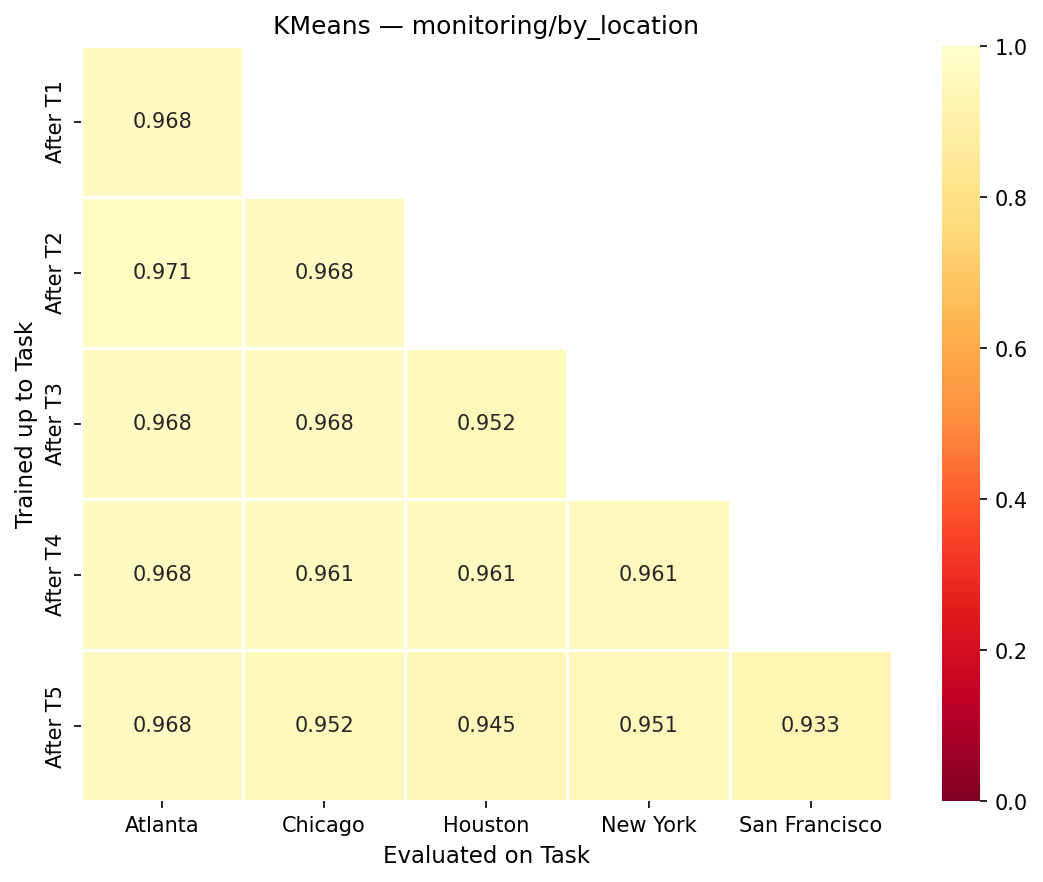

In [3]:
fig = plot_accuracy_matrix(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — monitoring/by_location",
)
save_figure(fig, FIGURES_DIR / "acc_matrix.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix.png")))

## Section 4 — Courbe d'oubli par tâche

AF attendu ≈ 0.0113 — légèrement plus élevé qu'en by_equipment (AF=0.0049).  
Le drift géographique induit plus de variabilité inter-tâches pour K-Means.

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location/forgetting_curve.png


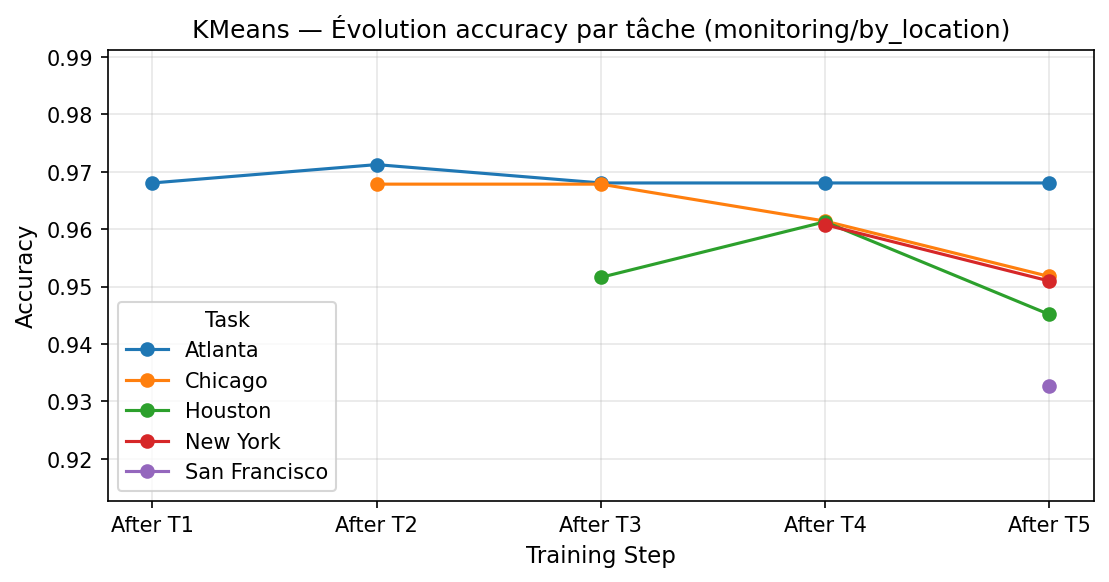

In [4]:
fig = plot_forgetting_curve(
    acc_matrix_np,
    task_names=TASK_NAMES,
    title=f"{MODEL_NAME} — Évolution accuracy par tâche (monitoring/by_location)",
)
save_figure(fig, FIGURES_DIR / "forgetting_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "forgetting_curve.png")))

## Section 5 — Rejeu du scénario CL

Entraîne K-Means séquentiellement sur les 5 villes et évalue sur toutes les tâches vues.  
Collecte `preds_dict[(i,j)]` et `scores_dict[(i,j)]` nécessaires pour les sections 6, 7 et 8.

In [5]:
from sklearn.metrics import accuracy_score, roc_auc_score

preds_dict    = {}  # (i, j) → (y_true, y_pred_binary)
scores_dict   = {}  # (i, j) → anomaly_scores (distance minimale centroïde)
X_tasks       = []
y_true_tasks  = []
y_pred_tasks  = []
cluster_tasks = []

if DATA_AVAILABLE:
    from src.data.monitoring_dataset import get_cl_dataloaders_by_location
    from src.models.unsupervised.kmeans_detector import KMeansDetector
    from src.utils.reproducibility import set_seed

    set_seed(42)

    # Charger la config KMeans
    full_config = yaml.safe_load(CONFIG_PATH.read_text())
    kmeans_cfg  = full_config["kmeans"]

    tasks = get_cl_dataloaders_by_location(
        csv_path=CSV_PATH,
        normalizer_path=NORMALIZER_PATH,
        batch_size=256,
        seed=42,
        location_order=TASK_NAMES,
    )

    # Extraire les données de validation en numpy une seule fois
    for t in tasks:
        X_v = np.concatenate([b[0].numpy() for b in t["val_loader"]])
        y_v = np.concatenate([b[1].numpy().flatten() for b in t["val_loader"]])
        X_tasks.append(X_v)
        y_true_tasks.append(y_v)

    detector = KMeansDetector(kmeans_cfg)

    for i, task in enumerate(tasks):
        domain = task.get("domain", TASK_NAMES[i])
        print(f"\n--- Tâche {i + 1}/{len(TASK_NAMES)} : {domain} ---")

        # Fit K-Means sans labels
        X_train = np.concatenate([b[0].numpy() for b in task["train_loader"]])
        detector.fit_task(X_train, task_id=i)

        # Évaluation sur toutes les tâches vues jusqu'à i
        for j in range(i + 1):
            scores   = detector.anomaly_score(X_tasks[j])
            y_pred   = detector.predict(X_tasks[j])
            clusters = detector.kmeans_.predict(X_tasks[j]) if hasattr(detector, "kmeans_") else np.zeros(len(X_tasks[j]), dtype=int)
            preds_dict[(i, j)]  = (y_true_tasks[j], y_pred.astype(float))
            scores_dict[(i, j)] = scores
            if i == len(TASK_NAMES) - 1:  # Garder les clusters du modèle final
                cluster_tasks.append(clusters)
                y_pred_tasks.append(y_pred)
            acc_j   = accuracy_score(y_true_tasks[j], y_pred)
            auroc_j = roc_auc_score(y_true_tasks[j], scores) if len(np.unique(y_true_tasks[j])) >= 2 else float("nan")
            print(f"  preds_dict[({i},{j})] → N={len(y_true_tasks[j])}, acc={acc_j:.4f}, AUROC={auroc_j:.4f}")

    print(f"\nScénario CL rejoué — {len(preds_dict)} évaluations collectées")

else:
    display(Markdown("> ⚠️ **Mode dégradé** — CSV absent. preds_dict synthétique depuis acc_matrix."))

    T = len(TASK_NAMES)
    N_SYNTH = 500
    rng = np.random.default_rng(42)
    y_synth = np.concatenate([np.zeros(N_SYNTH // 2), np.ones(N_SYNTH // 2)])

    for i in range(T):
        for j in range(i + 1):
            auroc_ij = metrics["auroc_per_task"][j] if j < len(metrics.get("auroc_per_task", [])) else 0.97
            noise = rng.normal(0, 0.1, N_SYNTH)
            scores_synth = np.where(y_synth == 1, 0.6 + noise, 0.3 + noise).clip(0, 1)
            threshold = np.percentile(scores_synth[:N_SYNTH // 2], 95)
            y_pred_synth = (scores_synth > threshold).astype(float)
            preds_dict[(i, j)]  = (y_synth.copy(), y_pred_synth)
            scores_dict[(i, j)] = scores_synth.astype(np.float32)

    print("preds_dict synthétique créé (mode dégradé — CSV absent)")

✅ Seed fixé à 42
✅ Seed fixé à 42

--- Tâche 1/5 : Atlanta ---
  [KMeans] Tâche 0 — K sélectionné : 2 (méthode=silhouette)
  [KMeans] Seuil calculé sur Task 0 : 3.6692 (percentile 95)
  preds_dict[(0,0)] → N=313, acc=0.9681, AUROC=0.9434

--- Tâche 2/5 : Chicago ---
  [KMeans] Tâche 1 — K sélectionné : 2 (méthode=silhouette)
  preds_dict[(1,0)] → N=313, acc=0.9712, AUROC=0.9682
  preds_dict[(1,1)] → N=311, acc=0.9678, AUROC=0.9955

--- Tâche 3/5 : Houston ---
  [KMeans] Tâche 2 — K sélectionné : 2 (méthode=silhouette)
  preds_dict[(2,0)] → N=313, acc=0.9681, AUROC=0.9578
  preds_dict[(2,1)] → N=311, acc=0.9678, AUROC=0.9934
  preds_dict[(2,2)] → N=310, acc=0.9516, AUROC=0.9896

--- Tâche 4/5 : New York ---
  [KMeans] Tâche 3 — K sélectionné : 2 (méthode=silhouette)
  preds_dict[(3,0)] → N=313, acc=0.9681, AUROC=0.9596
  preds_dict[(3,1)] → N=311, acc=0.9614, AUROC=0.9916
  preds_dict[(3,2)] → N=310, acc=0.9613, AUROC=0.9891
  preds_dict[(3,3)] → N=306, acc=0.9608, AUROC=0.9440

--- Tâc

## Section 6 — Matrices de confusion par tâche (grille 5×5)

Chaque panneau correspond à une évaluation (modèle après tâche i, évalué sur tâche j).  
Les matrices sont normalisées par ligne (recall par classe).

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location/confusion_matrix_grid.png


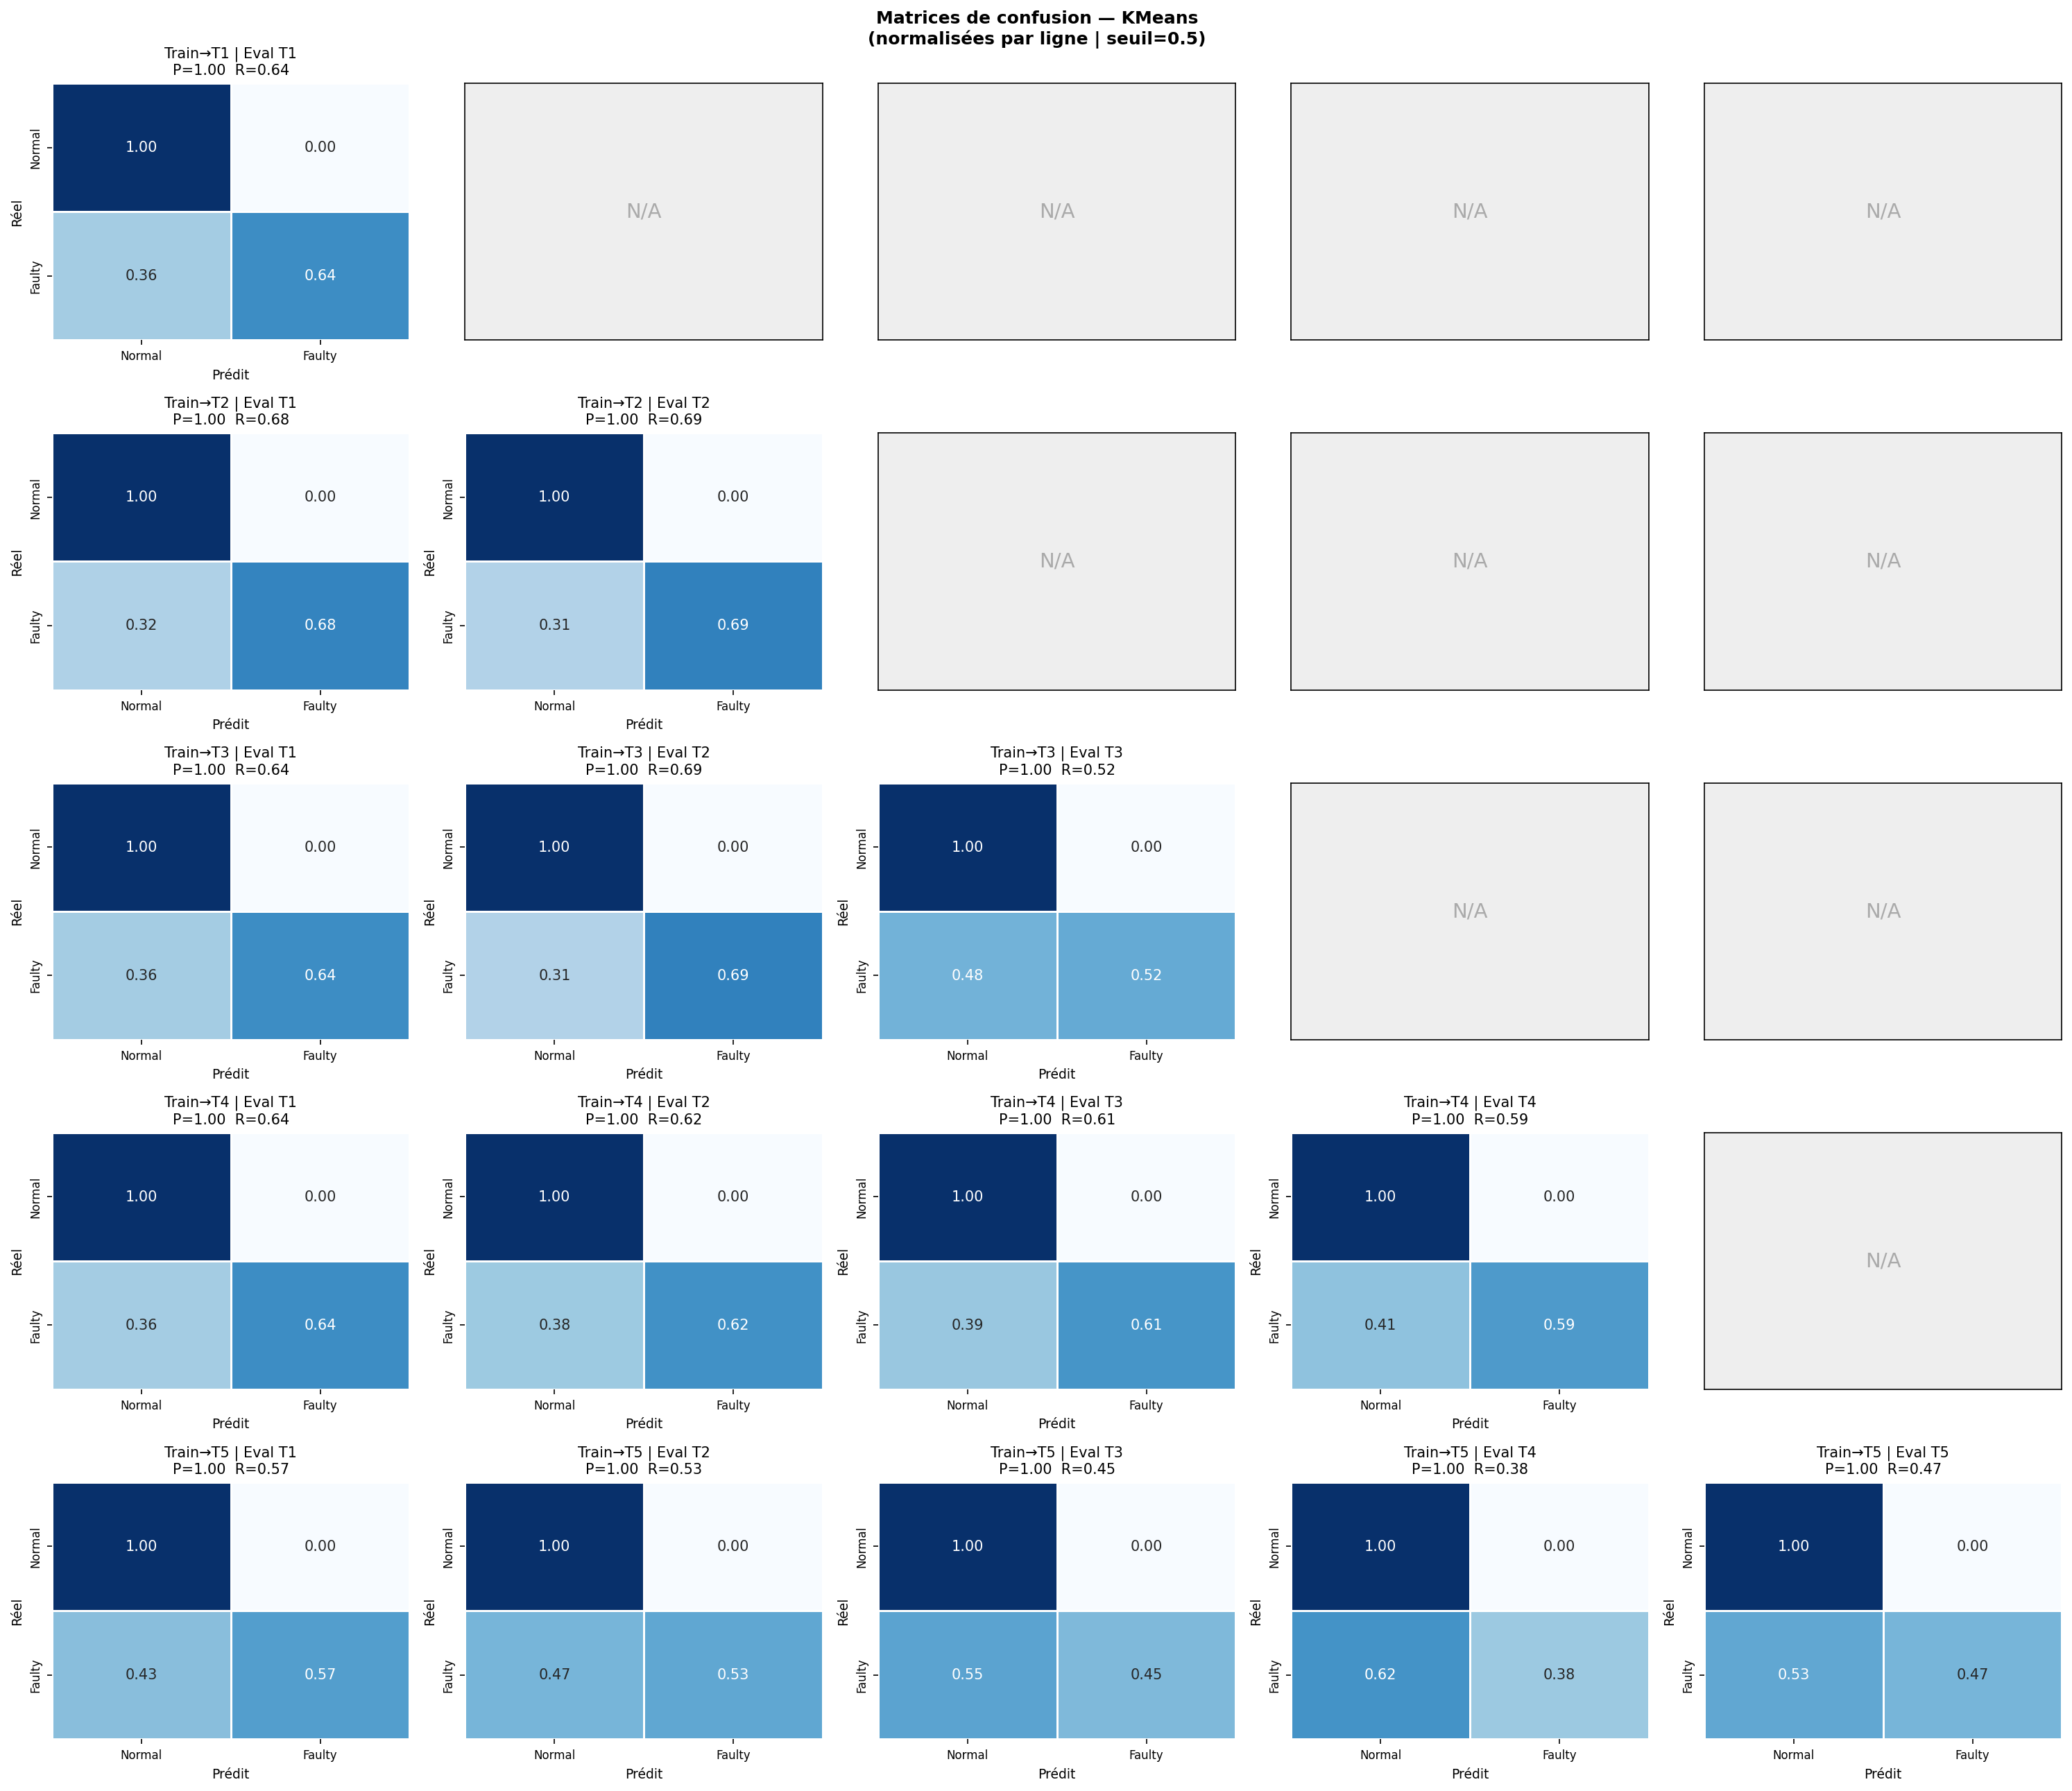

In [6]:
fig = plot_confusion_matrix_grid(
    preds_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
    threshold=0.5,
)
save_figure(fig, FIGURES_DIR / "confusion_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "confusion_matrix_grid.png")))

## Section 7 — Courbes AUROC par tâche (détection d'anomalie)

La distance minimale au centroïde le plus proche sert de score d'anomalie continu.  
AUROC attendu ≈ 0.9744 (moyenne des 5 tâches).

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location/auroc_curve.png


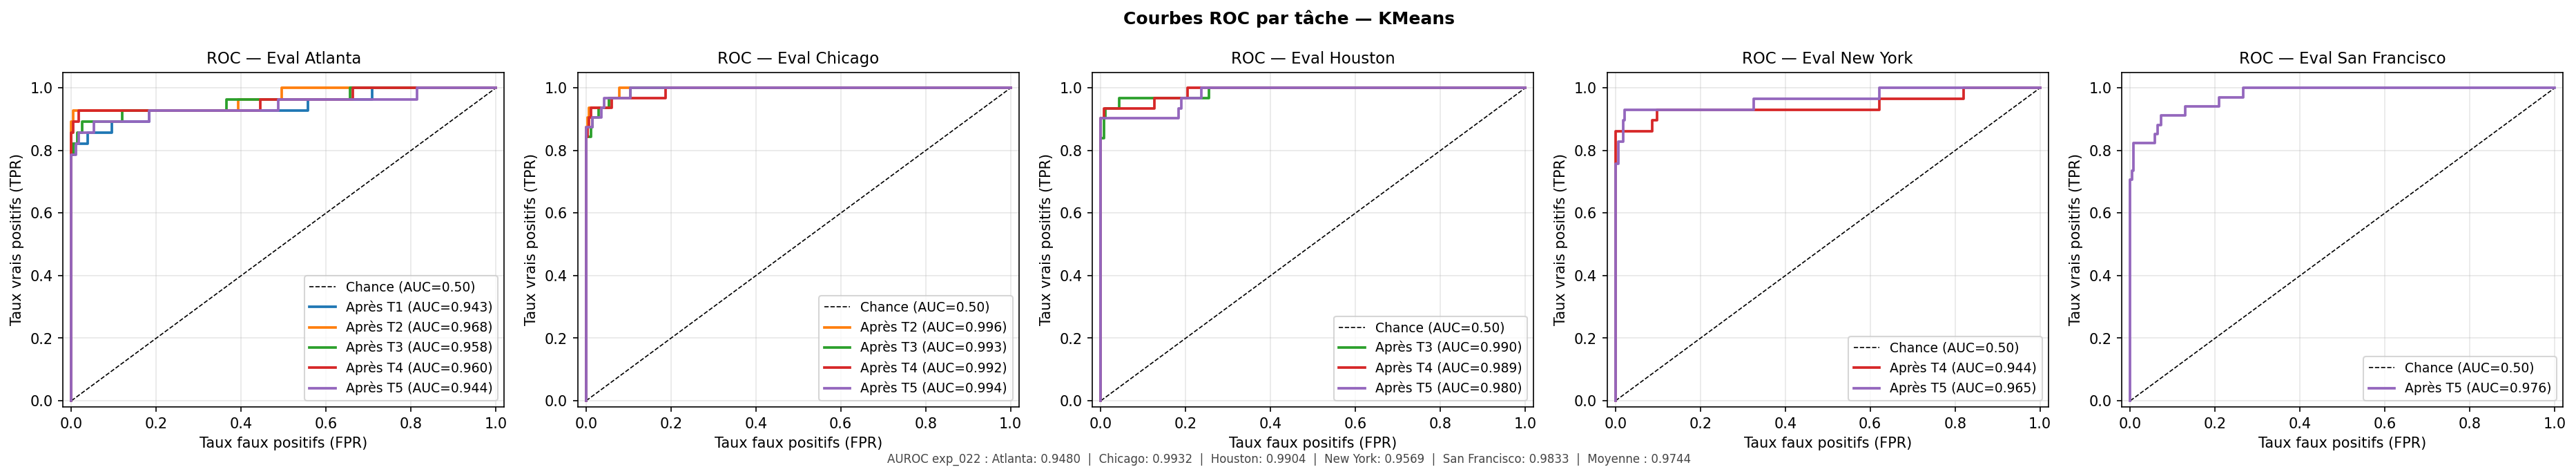

In [7]:
auroc_per_task = metrics.get("auroc_per_task", [])
fig = plot_roc_curves_per_task(
    preds_dict,
    scores_dict=scores_dict,
    task_names=TASK_NAMES,
    model_name=MODEL_NAME,
)

if auroc_per_task:
    auroc_str = "  |  ".join(
        f"{TASK_NAMES[j]}: {auroc_per_task[j]:.4f}" for j in range(len(auroc_per_task))
    )
    fig.text(
        0.5, 0.01,
        f"AUROC exp_022 : {auroc_str}  |  Moyenne : {metrics['auroc_avg']:.4f}",
        ha="center", fontsize=8, color="#444444",
    )

save_figure(fig, FIGURES_DIR / "auroc_curve.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "auroc_curve.png")))

## Section 8 — Espace des features (PCA 2D + centroïdes K-Means)

Projection PCA 2D des données de validation, colorées par ville d'origine.  
Les centroïdes du modèle final sont annotés pour chaque ville.

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/kmeans/monitoring/by_location/feature_space_pca.png


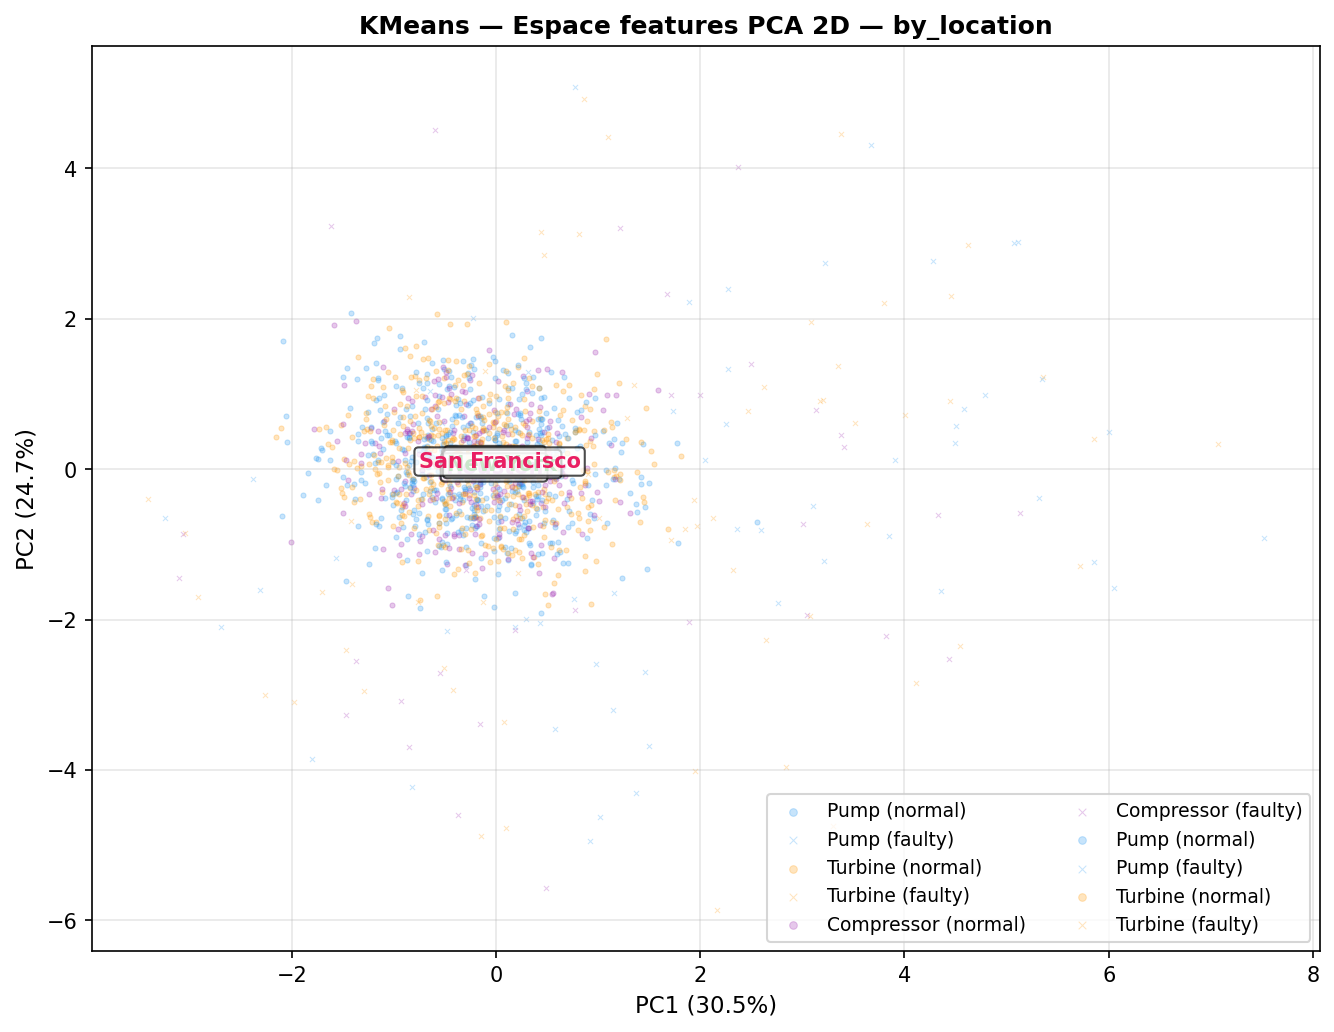

In [8]:
from src.evaluation.feature_space_plots import fit_pca2d, plot_feature_space_2d

if DATA_AVAILABLE and len(X_tasks) == len(TASK_NAMES):
    # Concaténer toutes les données de validation
    X_all      = np.concatenate(X_tasks, axis=0)   # [N_total, 4]
    y_all      = np.concatenate(y_true_tasks, axis=0)  # [N_total]
    domain_ids = np.concatenate([
        np.full(len(X_tasks[k]), k) for k in range(len(TASK_NAMES))
    ])  # [N_total]

    # Projection PCA 2D globale
    pca, X_proj = fit_pca2d(X_all)
    expl_var = pca.explained_variance_ratio_
    xlabel = f"PC1 ({expl_var[0]*100:.1f}%)"
    ylabel = f"PC2 ({expl_var[1]*100:.1f}%)"

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_feature_space_2d(
        X_proj, y_all,
        title=f"{MODEL_NAME} — Espace features PCA 2D — by_location",
        ax=ax,
        domain_ids=domain_ids,
        alpha=0.25,
        s=6,
        xlabel=xlabel,
        ylabel=ylabel,
    )

    TASK_COLORS = ["#2196F3", "#FF9800", "#9C27B0", "#4CAF50", "#E91E63"]
    for k, (name, color) in enumerate(zip(TASK_NAMES, TASK_COLORS)):
        mask = domain_ids == k
        cx, cy = X_proj[mask, 0].mean(), X_proj[mask, 1].mean()
        ax.annotate(
            name,
            xy=(cx, cy),
            fontsize=10,
            fontweight="bold",
            color=color,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.tight_layout()
    save_figure(fig, FIGURES_DIR / "feature_space_pca.png")
    plt.close(fig)
    display(Image(str(FIGURES_DIR / "feature_space_pca.png")))

else:
    display(Markdown("> ⚠️ **Section 8 ignorée** — CSV absent ou scénario CL non rejoué."))
    print("[SKIP] feature_space_pca.png")

## Section 9 — Tableau récapitulatif

Valeurs attendues : AA=0.9497 | AF=0.0113 | BWT=−0.0081 | AUROC=0.9744 | RAM=5.28 Ko | Latence=0.308 ms

> `FIXME(gap3)` : K-Means ne nécessite pas de labels à l'entraînement — avantage documenté ici :  
> économie de coût d'annotation en production industrielle (pas de labellisation de pannes requise).  
> AF légèrement plus élevé en by_location (0.0113) qu'en by_equipment (0.0049) — drift géographique plus complexe pour K-Means.

In [9]:
aa    = metrics["aa"]
af    = metrics["af"]
bwt   = metrics["bwt"]
auroc = metrics["auroc_avg"]
ram_ko = ram_b / 1024
forgetting_per_task = metrics.get("forgetting_per_task", [])

display(Markdown("### Résultats finaux — KMeans — monitoring/by_location (exp_022)"))

recap_table = f"""
| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| {MODEL_NAME} | {aa:.4f} | {af:.4f} | {bwt:+.4f} | {auroc:.4f} | {ram_ko:.2f} Ko | {lat:.5f} ms | {n_par} |
"""
display(Markdown(recap_table))

print(f"Forgetting par tâche (Atlanta→Chicago→Houston→New York) : {[round(v, 4) for v in forgetting_per_task]}")
print()
print("=" * 60)
print("  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)")
print("=" * 60)
print(f"  RAM = {ram_b} B = {ram_ko:.2f} Ko")
print(f"  Budget STM32N6 : 65 536 B (64 Ko)")
print(f"  Marge disponible : {65536 - ram_b} B ({(65536 - ram_b)/1024:.1f} Ko)")
print(f"  KMeans occupe {ram_b / 65536 * 100:.2f}% du budget RAM")
print()
print("  FIXME(gap2) : 5 tâches × k centroïdes × d features × 4B")
print("                À vérifier si centroïdes sauvegardés par tâche ou seulement dernière.")
print()

print("=" * 60)
print("  Critères d'acceptation (S7-10)")
print("=" * 60)
for fig_name in ["acc_matrix.png", "forgetting_curve.png", "confusion_matrix_grid.png",
                 "auroc_curve.png", "feature_space_pca.png"]:
    status = "OK" if (FIGURES_DIR / fig_name).exists() else "MANQUANTE"
    print(f"  [{status}] {fig_name}")

print()
print(f"  [{'OK' if abs(aa - 0.9497) < 0.01 else 'WARN'}] AA     = {aa:.4f}  (attendu ≈ 0.9497)")
print(f"  [{'OK' if abs(af - 0.0113) < 0.005 else 'WARN'}] AF     = {af:.4f}  (attendu ≈ 0.0113)")
print(f"  [{'OK' if abs(bwt - (-0.0081)) < 0.005 else 'WARN'}] BWT    = {bwt:+.4f} (attendu ≈ -0.0081)")
print(f"  [{'OK' if abs(auroc - 0.9744) < 0.005 else 'WARN'}] AUROC  = {auroc:.4f}  (attendu ≈ 0.9744)")
print(f"  [{'OK' if ram_b <= 65536 else 'FAIL (Gap2)'}] RAM    = {ram_ko:.2f} Ko (contrainte ≤ 64 Ko)")
print(f"  [{'OK' if lat < 100.0 else 'WARN'}] Latence= {lat:.5f} ms (contrainte ≤ 100 ms)")

### Résultats finaux — KMeans — monitoring/by_location (exp_022)


| Modèle | AA ↑ | AF ↓ | BWT | AUROC ↑ | RAM ↓ | Latence ↓ | n_params |
|--------|------|------|-----|---------|-------|-----------|----------|
| KMeans | 0.9497 | 0.0113 | -0.0081 | 0.9744 | 5.28 Ko | 0.30765 ms | 12 |


Forgetting par tâche (Atlanta→Chicago→Houston→New York) : [0.0032, 0.0161, 0.0161, 0.0098]

  NOTE SCIENTIFIQUE — Gap 2 (contrainte embarquée STM32N6)
  RAM = 5410 B = 5.28 Ko
  Budget STM32N6 : 65 536 B (64 Ko)
  Marge disponible : 60126 B (58.7 Ko)
  KMeans occupe 8.26% du budget RAM

  FIXME(gap2) : 5 tâches × k centroïdes × d features × 4B
                À vérifier si centroïdes sauvegardés par tâche ou seulement dernière.

  Critères d'acceptation (S7-10)
  [OK] acc_matrix.png
  [OK] forgetting_curve.png
  [OK] confusion_matrix_grid.png
  [OK] auroc_curve.png
  [OK] feature_space_pca.png

  [OK] AA     = 0.9497  (attendu ≈ 0.9497)
  [OK] AF     = 0.0113  (attendu ≈ 0.0113)
  [OK] BWT    = -0.0081 (attendu ≈ -0.0081)
  [OK] AUROC  = 0.9744  (attendu ≈ 0.9744)
  [OK] RAM    = 5.28 Ko (contrainte ≤ 64 Ko)
  [OK] Latence= 0.30765 ms (contrainte ≤ 100 ms)
